# 신용카드 사기 거래 탐지 프로젝트 — 데이터 탐색 (EDA)

이 노트북은 Impala에서 신용카드 거래 데이터를 불러와  
기본 통계와 사기율을 계산하고, 주요 패턴을 시각화합니다.

---

### 주요 목표
- Impala에서 데이터 로드  
- 기본 통계 및 사기율 확인  
- 주요 패턴 시각화  
  - 거래 시간대별 사기율  
  - 가맹점 카테고리별 사기율  
  - 국가별 사기율  
  - 거래 금액 분포 비교

In [1]:
import cml.data_v1 as cmldata
import pandas as pd
import seaborn as sns
from matplotlib import font_manager, rc
import matplotlib.pyplot as plt

# 한글 폰트 등록 (환경에 맞게 경로 수정 가능)
font_path = '/home/cdsw/fonts/NotoSansKR-VariableFont_wght.ttf'
font_manager.fontManager.addfont(font_path)
rc('font', family='Noto Sans KR')
rc('axes', unicode_minus=False)

print("✅ 기본 환경 설정 완료")

# ==========================
# 1️⃣ Impala 연결
# ==========================
CONNECTION_NAME = "default-impala-aws"
conn = cmldata.get_connection(CONNECTION_NAME)

print("="*70)
print("✅ Impala 연결 성공")
print("="*70)

✅ 기본 환경 설정 완료
✅ Impala 연결 성공


In [3]:
# ==========================
# 2️⃣ 분석용 데이터 로드
# ==========================
QUERY = """
SELECT *
FROM hwhwang_finance_db.credit_card_transactions
WHERE rand() <= 0.02
"""

df = conn.get_pandas_dataframe(QUERY)
print(f"데이터 로드 완료 ✅ : {df.shape[0]:,}건, {df.shape[1]}컬럼")
df.head()

데이터 로드 완료 ✅ : 20,495건, 15컬럼


,transaction_id,customer_id,transaction_date,transaction_amount,merchant_category,card_present,transaction_country,customer_age,customer_income_level,transaction_hour,is_weekend,days_since_last_transaction,avg_amount_last_30days,num_transactions_24h,is_fraud
0,TXN0000086326,CUST00036864,2024-01-01 00:55:00,2176.00,편의점,True,KR,43,HIGH,0,False,12,2385.00,2,0
1,TXN0000103009,CUST00060857,2024-01-01 01:07:00,294925.00,해외온라인쇼핑,False,TH,30,MEDIUM,1,False,4,312933.00,1,0
2,TXN0000466898,CUST00057193,2024-01-01 01:08:00,16140.00,일반음식점,True,KR,23,MEDIUM,1,False,7,16456.00,0,0
3,TXN0000745948,CUST00018655,2024-01-01 01:28:00,1247893.00,명품온라인쇼핑,True,KR,38,MEDIUM,1,False,3,929046.00,0,0
4,TXN0000983642,CUST00028920,2024-01-01 02:50:00,749893.00,해외숙박예약,False,TH,34,MEDIUM,2,False,5,628153.00,2,0


In [4]:
# ==========================
# 3️⃣ 기본 통계 & 사기율
# ==========================
total = len(df)
fraud = df['is_fraud'].sum()
fraud_rate = round(df['is_fraud'].mean() * 100, 3)

print("\n[데이터 요약]")
print(f"- 전체 거래 수: {total:,}")
print(f"- 사기 거래 수: {fraud:,}")
print(f"- 사기율: {fraud_rate:.3f}%")

df.describe(include='all')


[데이터 요약]
- 전체 거래 수: 20,495
- 사기 거래 수: 439
- 사기율: 2.142%


,transaction_id,customer_id,transaction_date,transaction_amount,merchant_category,card_present,transaction_country,customer_age,customer_income_level,transaction_hour,is_weekend,days_since_last_transaction,avg_amount_last_30days,num_transactions_24h,is_fraud
count,20495,20495,20495,20495,20495,20495,20495,20495.000000,20495,20495.000000,20495,20495.000000,20495,20495.000000,20495.000000
unique,20495,18503,NaN,18771,14,2,7,NaN,4,NaN,2,NaN,19160,NaN,NaN
top,TXN0000400289,CUST00063604,NaN,1000.00,일반음식점,True,KR,NaN,MEDIUM,NaN,False,NaN,1176.00,NaN,NaN
freq,1,5,NaN,1046,3074,10306,16773,NaN,10199,NaN,14594,NaN,6,NaN,NaN
mean,NaN,NaN,2024-07-02 02:52:12.960234496,NaN,NaN,NaN,NaN,37.821859,NaN,11.615223,NaN,6.585362,NaN,2.001513,0.021420
min,NaN,NaN,2024-01-01 00:55:00,NaN,NaN,NaN,NaN,20.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,0.000000
25%,NaN,NaN,2024-04-02 00:50:00,NaN,NaN,NaN,NaN,29.000000,NaN,6.000000,NaN,2.000000,NaN,1.000000,0.000000
50%,NaN,NaN,2024-07-01 23:53:00,NaN,NaN,NaN,NaN,37.000000,NaN,12.000000,NaN,4.000000,NaN,2.000000,0.000000
75%,NaN,NaN,2024-09-30 22:16:00,NaN,NaN,NaN,NaN,46.000000,NaN,18.000000,NaN,9.000000,NaN,3.000000,0.000000
max,NaN,NaN,2024-12-31 23:34:00,NaN,NaN,NaN,NaN,80.000000,NaN,23.000000,NaN,72.000000,NaN,10.000000,1.000000


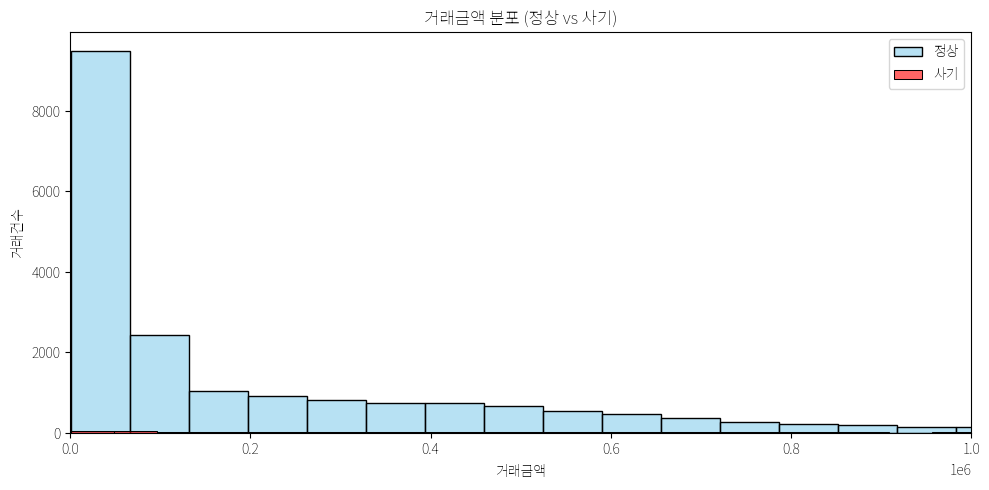

In [5]:
# ==========================
# 4️⃣ 거래 금액 분포 (정상 vs 사기)
# ==========================
plt.figure(figsize=(10,5))
sns.histplot(df[df['is_fraud']==0]['transaction_amount'], bins=50,
             color='skyblue', label='정상', alpha=0.6)
sns.histplot(df[df['is_fraud']==1]['transaction_amount'], bins=50,
             color='red', label='사기', alpha=0.6)
plt.xlim(0, 1_000_000)
plt.legend()
plt.title("거래금액 분포 (정상 vs 사기)")
plt.xlabel("거래금액")
plt.ylabel("거래건수")
plt.tight_layout()
plt.show()

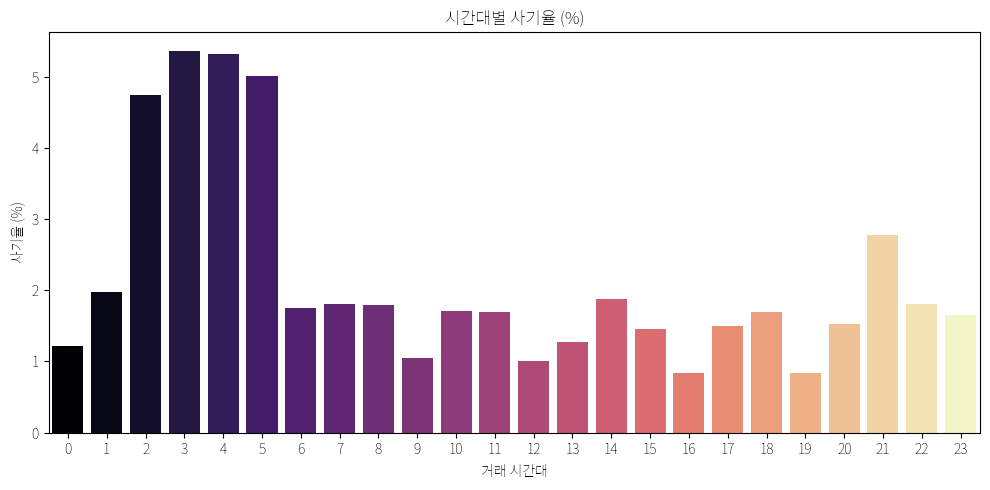

In [6]:
# ==========================
# 5️⃣ 시간대별 사기율
# ==========================
hourly = df.groupby('transaction_hour')['is_fraud'].mean().reset_index()
hourly['fraud_rate'] = hourly['is_fraud'] * 100

plt.figure(figsize=(10,5))
sns.barplot(x='transaction_hour', y='fraud_rate', data=hourly,
            hue='transaction_hour', palette='magma', legend=False)
plt.title("시간대별 사기율 (%)")
plt.xlabel("거래 시간대")
plt.ylabel("사기율 (%)")
plt.tight_layout()
plt.show()

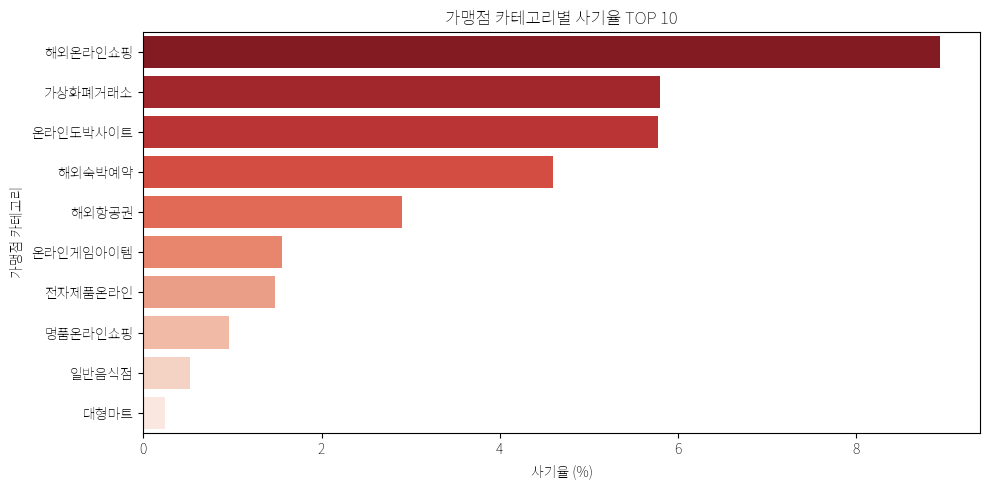

In [7]:
# ==========================
# 6️⃣ 카테고리별 사기율 Top 10
# ==========================
cat = df.groupby('merchant_category')['is_fraud'].mean().reset_index()
cat['fraud_rate'] = cat['is_fraud'] * 100
cat = cat.sort_values('fraud_rate', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(y='merchant_category', x='fraud_rate', data=cat,
            hue='merchant_category', palette='Reds_r', legend=False)
plt.title("가맹점 카테고리별 사기율 TOP 10")
plt.xlabel("사기율 (%)")
plt.ylabel("가맹점 카테고리")
plt.tight_layout()
plt.show()

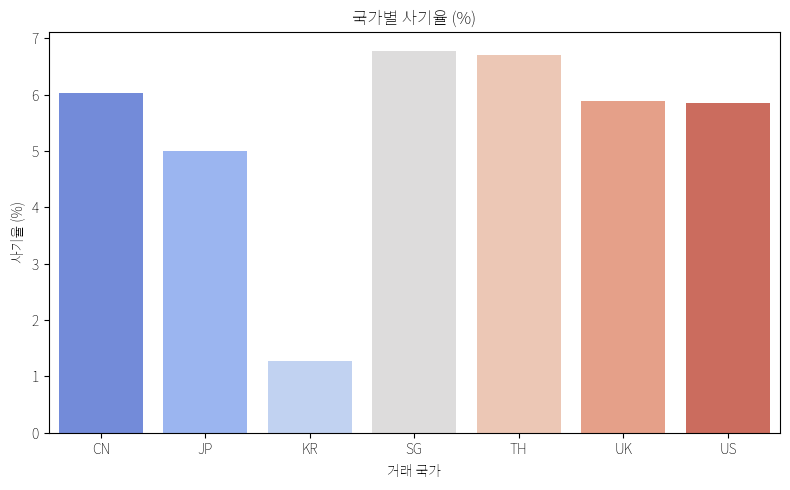

In [8]:
# ==========================
# 7️⃣ 국가별 사기율
# ==========================
country = df.groupby('transaction_country')['is_fraud'].mean().reset_index()
country['fraud_rate'] = country['is_fraud'] * 100

plt.figure(figsize=(8,5))
sns.barplot(x='transaction_country', y='fraud_rate', data=country,
            hue='transaction_country', palette='coolwarm', legend=False)
plt.title("국가별 사기율 (%)")
plt.xlabel("거래 국가")
plt.ylabel("사기율 (%)")
plt.tight_layout()
plt.show()

In [9]:
# ==========================
# 8️⃣ 종료
# ==========================
conn.close()
print("\n✅ 데이터 탐색(EDA) 완료 - 주요 패턴 시각화 완료")


✅ 데이터 탐색(EDA) 완료 - 주요 패턴 시각화 완료
